In [ ]:
# 처음 한 번만: 필요한 도구 설치 (이미 있으면 그냥 넘어갑니다)
%pip install pandas matplotlib statsmodels

# 도구 불러오기 + 작동 확인
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
print("환경 준비 완료! 파이썬이 잘 실행됩니다.")
print("pandas 버전:", pd.__version__)
print("statsmodels 버전:", statsmodels.__version__)

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------  9.7/9.8 MB 64.2 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 45.1 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 53.4 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 11.3/11.3 MB 53.7 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   --------------------------------- ------ 10.5/12.5 MB 71.2 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 41.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 29.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB

Matplotlib is building the font cache; this may take a moment.


환경 준비 완료! 파이썬이 잘 실행됩니다.
pandas 버전: 3.0.5
statsmodels 버전: 0.15.0


In [4]:
# 데이터를 인터넷에서 받아오는 도구 (없으면 설치)
%pip install requests

import requests
import pandas as pd
import os

# 창원의 위도·경도 (Open-Meteo가 이 좌표로 날씨를 찾아줍니다)
LAT, LON = 35.2281, 128.6811

# Open-Meteo 과거기상 아카이브 API 주소와 요청 조건
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2023-01-01",       # 시작일
    "end_date": "2025-12-31",         # 종료일 (3년치)
    "daily": "temperature_2m_mean",   # 하루 평균기온
    "timezone": "Asia/Seoul",
}

# 데이터 요청 → 결과 받기
response = requests.get(url, params=params)
data = response.json()

# 받은 데이터를 보기 좋은 '표(DataFrame)' 형태로 정리
df = pd.DataFrame({
    "날짜": data["daily"]["time"],
    "평균기온": data["daily"]["temperature_2m_mean"],
})
df["날짜"] = pd.to_datetime(df["날짜"])   # 글자를 '날짜'로 인식시키기

# data 폴더를 만들고 원본 데이터를 CSV 파일로 저장
os.makedirs("data", exist_ok=True)
df.to_csv("data/changwon_temperature_2023_2025.csv", index=False, encoding="utf-8-sig")

# 결과 확인
print("받아온 데이터 개수:", len(df), "개")
print("\n[처음 5줄]")
print(df.head())
print("\n[마지막 5줄]")
print(df.tail())
print("\ndata 폴더에 CSV로 저장 완료!")

Note: you may need to restart the kernel to use updated packages.
받아온 데이터 개수: 1096 개

[처음 5줄]
          날짜  평균기온
0 2023-01-01   2.2
1 2023-01-02   0.8
2 2023-01-03  -0.6
3 2023-01-04   0.2
4 2023-01-05   2.0

[마지막 5줄]
             날짜  평균기온
1091 2025-12-27  -0.4
1092 2025-12-28   3.9
1093 2025-12-29   7.2
1094 2025-12-30   3.7
1095 2025-12-31  -0.2

data 폴더에 CSV로 저장 완료!


In [5]:
# 1) 데이터가 어떻게 생겼는지 (처음 5줄)
print("[데이터 미리보기]")
print(df.head())

# 2) 데이터 기본 정보 (컬럼, 개수, 빈 값 여부)
print("\n[데이터 기본 정보]")
df.info()

# 3) 결측치(빈 값)가 몇 개인지 컬럼별로 확인
print("\n[결측치 개수]")
print(df.isnull().sum())

# 4) 숫자 요약 (최저/최고/평균 기온 등 — 이상치 힌트)
print("\n[기온 요약 통계]")
print(df["평균기온"].describe())

# 5) 날짜가 빠짐없이 이어지는지 확인 (기간과 실제 개수 비교)
기간_일수 = (df["날짜"].max() - df["날짜"].min()).days + 1
print(f"\n기간상 있어야 할 날 수: {기간_일수}일 / 실제 데이터: {len(df)}일")

[데이터 미리보기]
          날짜  평균기온
0 2023-01-01   2.2
1 2023-01-02   0.8
2 2023-01-03  -0.6
3 2023-01-04   0.2
4 2023-01-05   2.0

[데이터 기본 정보]
<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      1096 non-null   datetime64[us]
 1   평균기온    1096 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 17.3 KB

[결측치 개수]
날짜      0
평균기온    0
dtype: int64

[기온 요약 통계]
count    1096.000000
mean       15.048175
std         9.173192
min        -7.600000
25%         6.875000
50%        15.700000
75%        23.300000
max        30.600000
Name: 평균기온, dtype: float64

기간상 있어야 할 날 수: 1096일 / 실제 데이터: 1096일


In [6]:
# ── 5단계: 시계열 분석 (기법 3가지 적용) ──

# 날짜 순서대로 정렬 (시계열 분석의 기본)
df = df.sort_values("날짜").reset_index(drop=True)

# [기법 1] 이동평균 — 최근 7일·30일 평균선 (들쭉날쭉함을 걷어내고 '큰 흐름'을 봄)
df["이동평균_7일"]  = df["평균기온"].rolling(window=7).mean()
df["이동평균_30일"] = df["평균기온"].rolling(window=30).mean()

# [기법 2] 변화율 — 전날 대비 기온 변화 (변동이 큰 시기를 찾음)
df["전일대비변화"] = df["평균기온"].diff()

# [기법 3] 월별 집계 — 달마다 평균기온 (계절 패턴/가장 덥고 추운 달)
df["월"] = df["날짜"].dt.month
월별평균 = df.groupby("월")["평균기온"].mean()

# 연도별 평균기온 (추세 확인용)
df["연도"] = df["날짜"].dt.year
연도별평균 = df.groupby("연도")["평균기온"].mean()

# ── 결과 확인 ──
print("[이동평균이 추가된 표 (31~35번째 줄 예시)]")
print(df[["날짜","평균기온","이동평균_7일","이동평균_30일","전일대비변화"]].iloc[30:35].round(2))

print("\n[월별 평균기온 (1월~12월, 3년 평균)]")
print(월별평균.round(1))

print("\n[연도별 평균기온]")
print(연도별평균.round(2))

print("\n[전일 대비 변화가 가장 컸던 날 TOP 5]")
print(df.reindex(df["전일대비변화"].abs().sort_values(ascending=False).index)
        [["날짜","평균기온","전일대비변화"]].head(5).round(1))

[이동평균이 추가된 표 (31~35번째 줄 예시)]
           날짜  평균기온  이동평균_7일  이동평균_30일  전일대비변화
30 2023-01-31   1.5    -1.67      1.82     0.7
31 2023-02-01   6.4     0.33      2.01     4.9
32 2023-02-02   1.6     0.76      2.08    -4.8
33 2023-02-03   2.9     1.44      2.17     1.3
34 2023-02-04   1.3     2.13      2.15    -1.6

[월별 평균기온 (1월~12월, 3년 평균)]
월
1      2.1
2      4.0
3      9.1
4     14.1
5     17.6
6     22.5
7     26.3
8     27.6
9     24.5
10    17.5
11    10.6
12     4.2
Name: 평균기온, dtype: float64

[연도별 평균기온]
연도
2023    14.82
2024    15.42
2025    14.90
Name: 평균기온, dtype: float64

[전일 대비 변화가 가장 컸던 날 TOP 5]
             날짜  평균기온  전일대비변화
327  2023-11-24   4.7   -10.0
349  2023-12-16   3.8    -9.9
23   2023-01-24  -5.7    -9.3
350  2023-12-17  -4.2    -8.0
1085 2025-12-21   3.8    -7.9


C:\Users\USER\AppData\Local\Temp\ipykernel_61112\1810052164.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df[["날짜","평균기온","이동평균_7일","이동평균_30일","전일대비변화"]].iloc[30:35].round(2))
C:\Users\USER\AppData\Local\Temp\ipykernel_61112\1810052164.py:33: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  [["날짜","평균기온","전일대비변화"]].head(5).round(1))


In [7]:
# 연도별 평균기온만 따로 보기 (질문 1: 추세 확인)
print("[연도별 평균기온]")
print(연도별평균.round(2))

[연도별 평균기온]
연도
2023    14.82
2024    15.42
2025    14.90
Name: 평균기온, dtype: float64


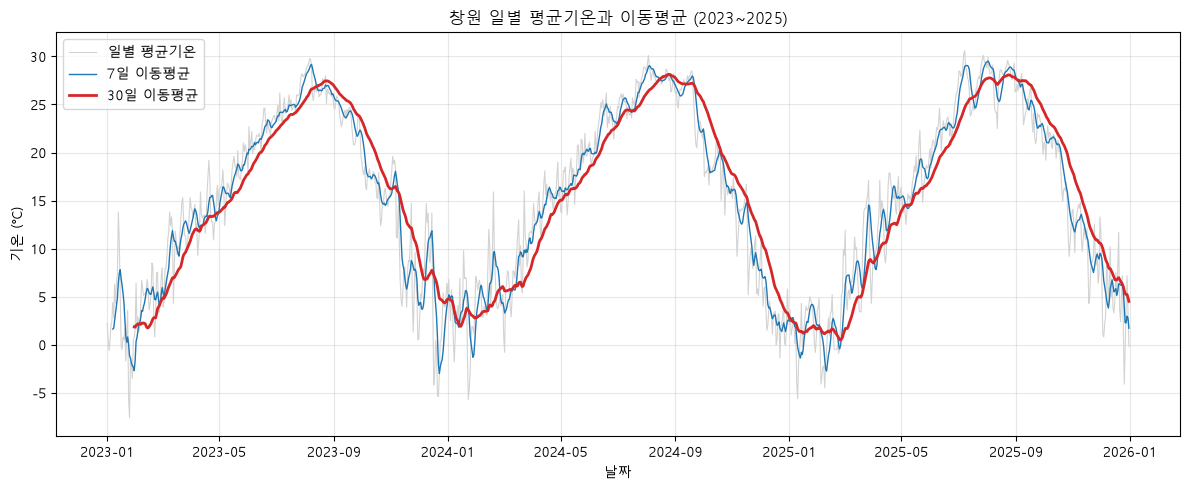

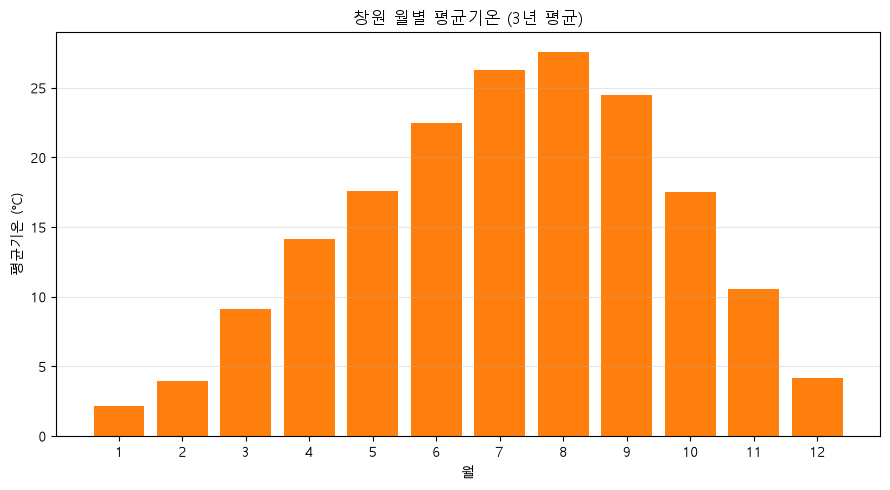

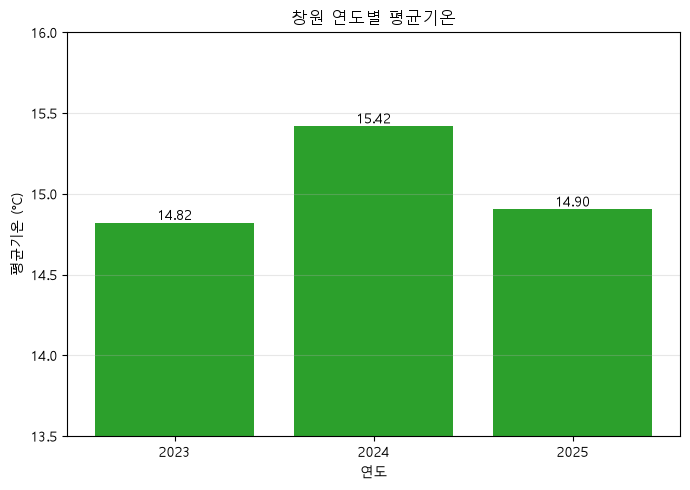

images 폴더에 그래프 3개 저장 완료!


In [8]:
import matplotlib.pyplot as plt
import os

# ★ 한글이 깨지지 않도록 폰트 설정 (윈도우) - 꼭 필요!
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 그래프를 저장할 images 폴더 만들기
os.makedirs("images", exist_ok=True)

# ── 그래프 1: 일별 기온 + 이동평균 (계절성 + 큰 흐름) ──
plt.figure(figsize=(12, 5))
plt.plot(df["날짜"], df["평균기온"], color="lightgray", linewidth=0.8, label="일별 평균기온")
plt.plot(df["날짜"], df["이동평균_7일"], color="tab:blue", linewidth=1, label="7일 이동평균")
plt.plot(df["날짜"], df["이동평균_30일"], color="tab:red", linewidth=2, label="30일 이동평균")
plt.title("창원 일별 평균기온과 이동평균 (2023~2025)")
plt.xlabel("날짜"); plt.ylabel("기온 (°C)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("images/01_기온추이_이동평균.png", dpi=150)
plt.show()

# ── 그래프 2: 월별 평균기온 (계절 패턴) ──
plt.figure(figsize=(9, 5))
plt.bar(월별평균.index, 월별평균.values, color="tab:orange")
plt.title("창원 월별 평균기온 (3년 평균)")
plt.xlabel("월"); plt.ylabel("평균기온 (°C)")
plt.xticks(range(1, 13)); plt.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig("images/02_월별평균기온.png", dpi=150)
plt.show()

# ── 그래프 3: 연도별 평균기온 (추세) ──
plt.figure(figsize=(7, 5))
bars = plt.bar(연도별평균.index.astype(str), 연도별평균.values, color="tab:green")
plt.bar_label(bars, fmt="%.2f")          # 막대 위에 숫자 표시
plt.title("창원 연도별 평균기온")
plt.xlabel("연도"); plt.ylabel("평균기온 (°C)")
plt.ylim(13.5, 16)                        # 작은 차이를 보기 쉽게 y축 확대
plt.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig("images/03_연도별평균기온.png", dpi=150)
plt.show()

print("images 폴더에 그래프 3개 저장 완료!")

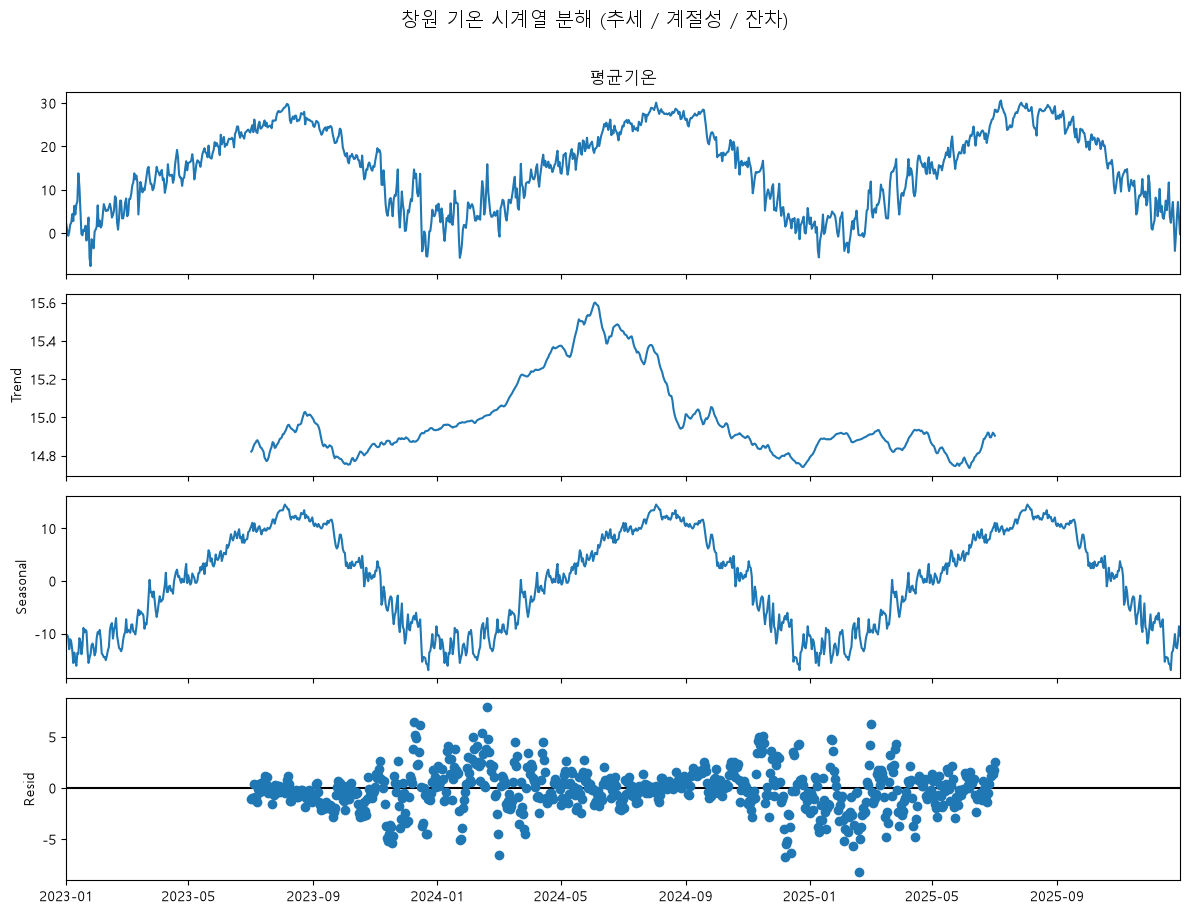

시계열 분해 그래프 저장 완료! (images/04_시계열분해.png)


In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 날짜를 기준(인덱스)으로 하는 시계열 데이터 만들기
ts = df.set_index("날짜")["평균기온"]

# 시계열 분해: 1년(365일) 주기로 '추세 / 계절성 / 잔차' 분리
result = seasonal_decompose(ts, model="additive", period=365)

# 4단 그래프로 그리기 (원본 / 추세 / 계절성 / 잔차)
fig = result.plot()
fig.set_size_inches(12, 9)
fig.suptitle("창원 기온 시계열 분해 (추세 / 계절성 / 잔차)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("images/04_시계열분해.png", dpi=150, bbox_inches="tight")
plt.show()

print("시계열 분해 그래프 저장 완료! (images/04_시계열분해.png)")